# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.DataFrame({"Expressao": np.random.normal(0,3,1000)})
df.head()

,Expressao
0,-1.031331
1,2.315130
2,1.519318
3,-0.209505
4,-0.828090


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [4]:
array_int = np.random.randint(1000)

array_int

878

OBS: Não entendi a proposta do exercício. Usei o método para gerar um número que corresponde aos genes diferencialmente expressos, mas de 1000 pacientes? Achei confuso por que no exercício anterior gerei valores negativos (down) e positivos (up) automaticamente.

## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os dados de expressão gênica foram categorizados em 6 grupos por meio de discretização (binning), utilizando intervalos definidos entre -3 e 3. Esses intervalos foram escolhidos com base na distribuição normal dos dados gerados, que possui média zero. Valores negativos representam genes downregulated, enquanto valores positivos representam genes upregulated. A divisão em faixas permite classificar os níveis de expressão em diferentes intensidades, desde fortemente downregulated até fortemente upregulated.

In [5]:
categoria = [-3, -2, -1, 0, 1, 2, 3]

df['categoria'] = pd.cut(df['Expressao'], bins=categoria, labels=['A', 'B', 'C', 'D', 'E', 'F'])

df.head()

,Expressao,categoria
0,-1.031331,B
1,2.315130,F
2,1.519318,E
3,-0.209505,C
4,-0.828090,C


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [6]:
def tabela_frequencia(serie: pd.Series) -> pd.DataFrame:
    '''
        Recebe um pd.Series, que no caso pode ser a coluna de Expressão do df original.
        Retorna outra df, contendo a frequência relativa.
    '''

    freq_rel = serie.value_counts(normalize=True).sort_index()
    
    tabela = pd.DataFrame({
        'freq_rel': freq_rel,
    })
    
    return tabela

In [7]:
#  Tabela de frequencia total
frequencia_expressão = tabela_frequencia(df['Expressao'])
frequencia_expressão.head()

,freq_rel
Expressao,
-8.897480,0.001
-8.635477,0.001
-7.857102,0.001
-7.775465,0.001
-7.567131,0.001


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

<Axes: xlabel='Expressao'>

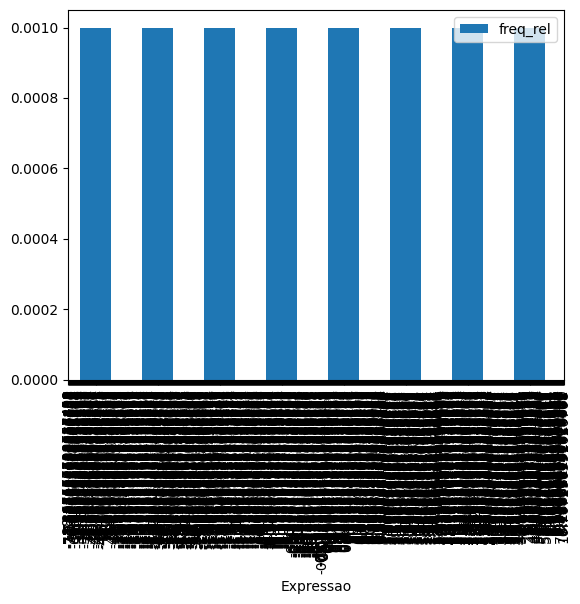

In [9]:
frequencia_expressão.plot.bar()

<Axes: xlabel='Expressao'>

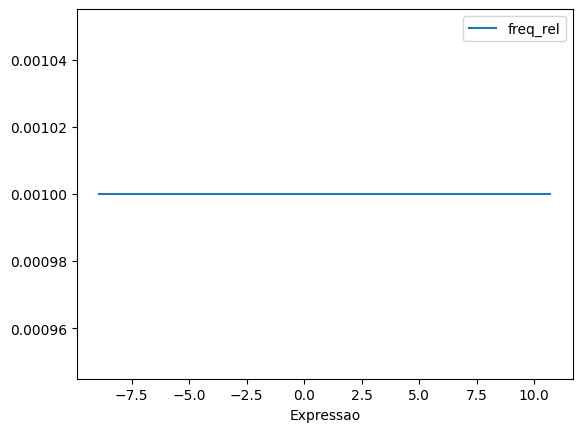

In [10]:
frequencia_expressão.plot.line()

### Número

In [11]:
#  Tabela de frequencia da outra variavel
frequencia_categoria = tabela_frequencia(df['categoria'])
frequencia_categoria.head()

,freq_rel
categoria,
A,0.143485
B,0.177160
C,0.183016
D,0.178624
E,0.162518


<Axes: xlabel='categoria'>

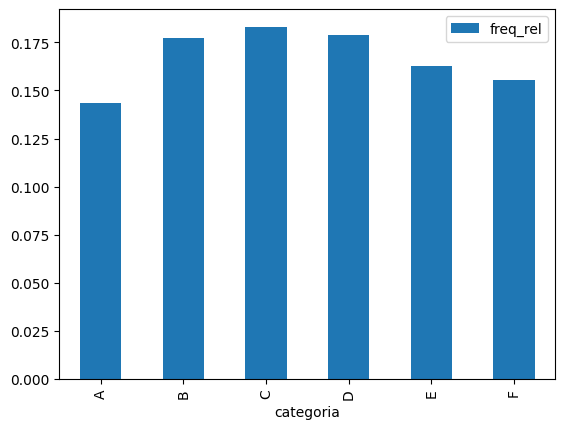

In [12]:
frequencia_categoria.plot.bar()

<Axes: xlabel='categoria'>

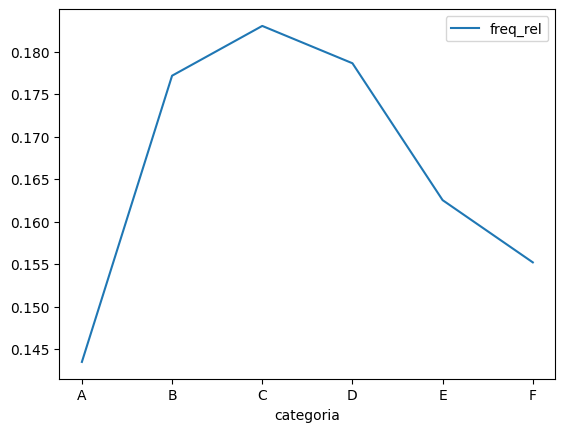

In [13]:
frequencia_categoria.plot.line()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

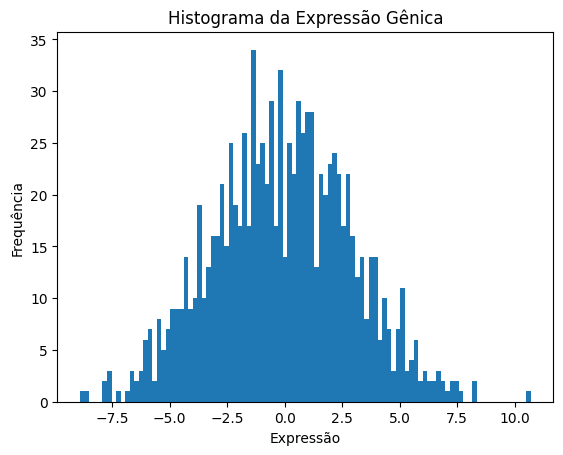

In [16]:
plt.hist(df['Expressao'], bins=100)
plt.title('Histograma da Expressão Gênica')
plt.xlabel('Expressão')
plt.ylabel('Frequência')

plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

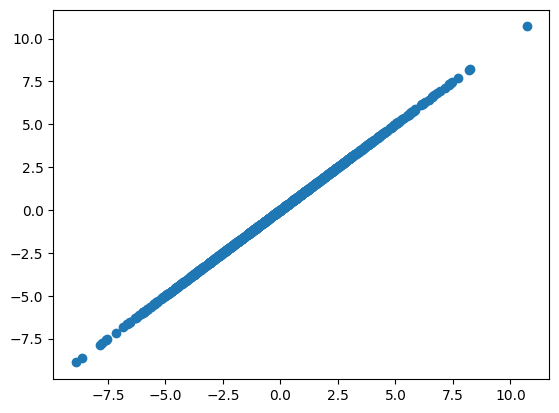

In [24]:
plt.scatter(df['Expressao'], df['Expressao'])

plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

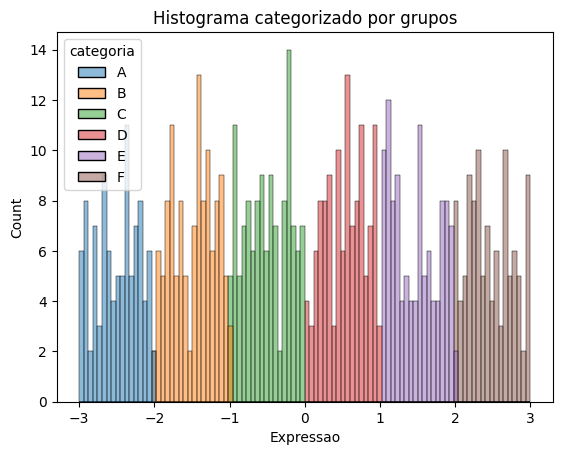

In [26]:
sns.histplot(data=df, x='Expressao', hue='categoria', bins=100)

plt.title('Histograma categorizado por grupos')
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

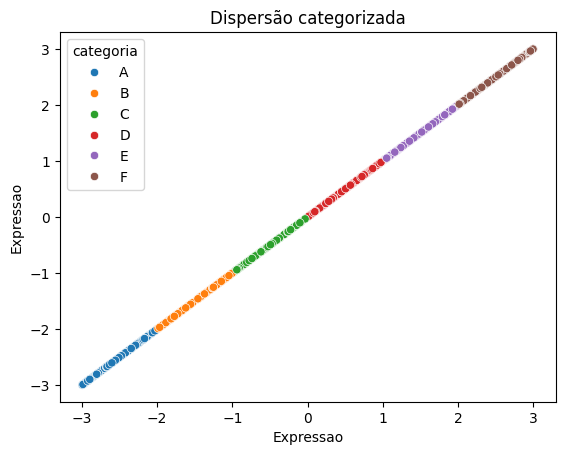

In [28]:
sns.scatterplot(
    data=df,
    x='Expressao',
    y='Expressao',
    hue='categoria'
)

plt.title('Dispersão categorizada')
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

| Variável                | Tipo         |
| ----------------------- | ------------ |
| # de células positivas  | **Discreta** |
| % de células positivas  | **Contínua** |
| Faixa de pH             | **Ordinal**  |
| Valor de pH             | **Contínua** |
| mol/L                   | **Contínua** |
| UFC                     | **Discreta** |
| D.O. (densidade óptica) | **Contínua** |
| Grupo Sanguíneo         | **Nominal**  |
| Sorologia               | **Nominal**  |
